

Ryan Dunne C00263405

Medical Student Dataset - Link: https://www.kaggle.com/datasets/slmsshk/medical-students-dataset

20,000 entries in order of Student ID where it isn't missing.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('medical_students_dataset.csv')



### Every series of the dataset has some missing values



In [3]:
print(df)

        Student ID   Age  Gender      Height     Weight Blood Type        BMI  \
0              1.0  18.0  Female  161.777924  72.354947          O  27.645835   
1              2.0   NaN    Male  152.069157  47.630941          B        NaN   
2              3.0  32.0  Female  182.537664  55.741083          A  16.729017   
3              NaN  30.0    Male  182.112867  63.332207          B  19.096042   
4              5.0  23.0  Female         NaN  46.234173          O        NaN   
...            ...   ...     ...         ...        ...        ...        ...   
199995         NaN  24.0    Male  176.503260  95.756997          B  30.737254   
199996     99997.0  29.0  Female  163.917675  45.225194        NaN  16.831734   
199997     99998.0  34.0  Female         NaN  99.648914        NaN  33.189303   
199998     99999.0  30.0  Female  156.446944  50.142824          A  20.486823   
199999    100000.0  20.0  Female  153.927409  99.928405          O  42.175189   

        Temperature  Heart 



### To complete the Student ID series I:

#### 1. Found all NaN values
#### 2. Using the NaN mask, I found the previously NaN, now filled location index value & added 1

### All missing ID's are now filled in and ordered



In [4]:
isNullMask = df['Student ID'].isna()

print(isNullMask)

replacement_values = df.index[isNullMask] + 1
df.loc[isNullMask, 'Student ID'] = replacement_values


0         False
1         False
2         False
3          True
4         False
          ...  
199995     True
199996    False
199997    False
199998    False
199999    False
Name: Student ID, Length: 200000, dtype: bool


In [5]:
isNullMask = df['Student ID'].isna()
print(isNullMask) #Print new isNullMask for Student ID


0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Name: Student ID, Length: 200000, dtype: bool




Filled in missing Gender values by alternating between Male & Female to help maintain current Gender ratio



In [6]:
nullMask = df.loc[df['Gender'].isna(), 'Gender']
nullMaskIndex = nullMask.index

maleFemale = ['Male' if i % 2 == 0 else 'Female' for i in range(len(nullMaskIndex))]

df.loc[nullMaskIndex, 'Gender'] = maleFemale




### Found the mean Age for both Men & Women, imputed the rounded values where missing



In [7]:
isMale = df['Gender'] == 'Male'
isFemale = df['Gender'] == 'Female'

meanAgeMale = df.loc[isMale, 'Age'].mean().round()
meanAgeFemale = df.loc[isFemale, 'Age'].mean().round()

print("Average Male Age: ",meanAgeMale)
print("Average Female Age: ",meanAgeFemale)


df.loc[isMale & df['Age'].isna(), 'Age'] = meanAgeMale
df.loc[isFemale & df['Age'].isna(), 'Age'] = meanAgeFemale


Average Male Age:  26.0
Average Female Age:  26.0




### Got the mean height for each gender & imputed it into missing cells
                    


In [8]:
isMale = df['Gender'] == 'Male'
isFemale = df['Gender'] == 'Female'

meanHeightMale = df.loc[isMale, 'Height'].mean()
meanHeightFemale = df.loc[isFemale, 'Height'].mean()

print("Average Male Height: ",meanHeightMale)
print("Average Female Height: ",meanHeightFemale)

df.loc[isMale & df['Height'].isna(), 'Height'] = meanHeightMale
df.loc[isFemale & df['Height'].isna(), 'Height'] = meanHeightFemale


Average Male Height:  174.97280394464644
Average Female Height:  174.92141452528332




### Got the mean weight for each gender & imputed it into missing cells



In [9]:
isMale = df['Gender'] == 'Male'
isFemale = df['Gender'] == 'Female'

meanWeightMale = df.loc[isMale, 'Weight'].mean()
meanWeightFemale = df.loc[isFemale, 'Weight'].mean()

print("Average Male Weight: ",meanWeightMale)
print("Average Female Weight: ",meanWeightFemale)

df.loc[isMale & df['Weight'].isna(), 'Weight'] = meanWeightMale
df.loc[isFemale & df['Weight'].isna(), 'Weight'] = meanWeightFemale


Average Male Weight:  69.94502926088707
Average Female Weight:  69.99812971272695




### Used the mode to find the most common blood type & add it to missing fields



In [10]:
commonBloodType = df['Blood Type'].mode()
print("Most Common Blood Type: ",commonBloodType[0])

df.loc[df['Blood Type'].isna(), 'Blood Type'] = commonBloodType[0]


Most Common Blood Type:  B




### Caluclated & inputted mean BMI for Men & Women using the WHO standard formuala for calulating BMI

#### BMI =          Weight(kg)
 ---------------------------
####          (Height(cm) / 100) **2



In [11]:
isMale = df['Gender'] == 'Male'
isFemale = df['Gender'] == 'Female'

df.loc[df['BMI'].isna(), 'BMI'] = (
    df.loc[df['BMI'].isna(), 'Weight'] / ((df.loc[df['BMI'].isna(), 'Height']/100)**2))




### Found mean temperature for each gender & imputed values where NaN = True



In [12]:
isMale = df['Gender'] == 'Male'
isFemale = df['Gender'] == 'Female'

meanTemperatureMale = df.loc[isMale, 'Temperature'].mean()
meanTemperatureFemale = df.loc[isFemale, 'Temperature'].mean()

print("Average Male Temperature: ",meanTemperatureMale)
print("Average Female Temperature: ",meanTemperatureFemale)

df.loc[isMale & df['Temperature'].isna(), 'Temperature'] = meanTemperatureMale
df.loc[isFemale & df['Temperature'].isna(), 'Temperature'] = meanTemperatureFemale


Average Male Temperature:  98.60070035172478
Average Female Temperature:  98.60119593105755




### Found mean Heart Rate, rounded it & input into missing cells



In [13]:
averageHeartRate = np.ceil(df['Heart Rate'].mean().round(1))

print("Average Heart Rate: ",averageHeartRate)


df.loc[df['Heart Rate'].isna(), 'Heart Rate'] = averageHeartRate

Average Heart Rate:  80.0




### Found mean Blood Pressure & filled in missing values



In [14]:
averageBloodPressure = np.ceil(df['Blood Pressure'].mean())

print("Average Blood Pressure: ",averageBloodPressure)


df.loc[df['Blood Pressure'].isna(), 'Blood Pressure'] = averageBloodPressure

Average Blood Pressure:  115.0




### Found mean Cholesterol & filled in missing values



In [15]:
averageCholesterol = np.ceil(df['Cholesterol'].mean())

print("Average Cholesterol: ",averageCholesterol)


df.loc[df['Cholesterol'].isna(), 'Cholesterol'] = averageCholesterol

Average Cholesterol:  185.0




### Used mode to fill in remaining diabetes fields



In [16]:
isDiabetic = df['Diabetes'].mode()

print("Diabetic Mode: ",isDiabetic[0])


df.loc[df['Diabetes'].isna(), 'Diabetes'] = isDiabetic[0]

Diabetic Mode:  No




### Used mode from Diabetes series to fill in the last of the missing values



In [17]:
isSmoker = df['Smoking'].mode()

print("Smoking Mode: ",isSmoker[0])


df.loc[df['Smoking'].isna(), 'Smoking'] = isSmoker[0]

Smoking Mode:  No




### All data is now filled in, ready for use in a new csv file



In [18]:
print(df.head(20))
df.to_csv("completed_medical_students_dataset.csv")

    Student ID   Age  Gender      Height     Weight Blood Type        BMI  \
0          1.0  18.0  Female  161.777924  72.354947          O  27.645835   
1          2.0  26.0    Male  152.069157  47.630941          B  20.597139   
2          3.0  32.0  Female  182.537664  55.741083          A  16.729017   
3          4.0  30.0    Male  182.112867  63.332207          B  19.096042   
4          5.0  23.0  Female  174.921415  46.234173          O  15.110441   
5          6.0  32.0    Male  151.491294  68.647805          B  29.912403   
6          7.0  21.0  Female  172.949704  48.102744         AB  16.081635   
7          8.0  28.0    Male  186.489402  52.389752         AB  15.063921   
8          9.0  21.0    Male  155.039678  42.958703          B  17.871682   
9         10.0  32.0    Male  170.836315  50.783250          B  17.400435   
10        11.0  28.0  Female  152.973928  73.572814          B  31.440000   
11        12.0  34.0  Female  182.416302  76.371050         AB  22.950992   



### Reading in completed dataset



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv('completed_medical_students_dataset.csv')

xAxis = df[["BMI", "Cholesterol", "Blood Pressure"]] #Inputs to be used
yAxis = df['Diabetes'].map({'Yes': 1, 'No': 0}) #Converts Diabetes series to a numeric type

xTrain, xTest, yTrain, yTest = train_test_split(xAxis, yAxis, test_size = 0.30, random_state = 10)
#Using 30% of the Data as test data because theres over 20k entries

In [49]:
randomForest = RandomForestClassifier(
    n_estimators=1,
    max_depth = None,
    random_state = 10 )

randomForest.fit(xTrain, yTrain)

,n_estimators,1
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
yPrediction = randomForest.predict(xTest)
yProbability = randomForest.predict_proba(xTest)[:,1]

print(classification_report(yTest, yPrediction))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     54626
           1       0.34      0.33      0.34      5374

    accuracy                           0.88     60000
   macro avg       0.64      0.64      0.64     60000
weighted avg       0.88      0.88      0.88     60000



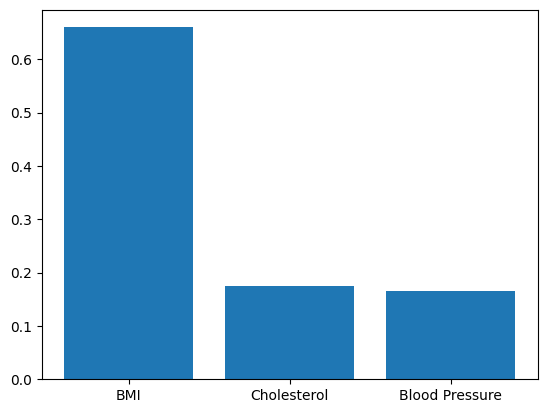

In [51]:
importance = randomForest.feature_importances_
features = xAxis.columns

plt.bar(features, importance)
plt.show()

In [52]:
print(randomForest)

RandomForestClassifier(n_estimators=1, random_state=10)


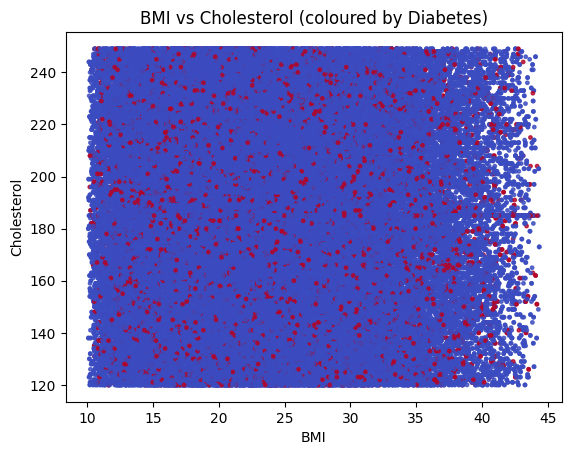

In [56]:
plt.scatter(df["BMI"], df["Cholesterol"], c=df["Diabetes"].map({"Yes":1,"No":0}), cmap="coolwarm", s=6, alpha=0.8)
plt.xlabel("BMI")
plt.ylabel("Cholesterol")
plt.title("BMI vs Cholesterol (coloured by Diabetes)")
plt.show()


C:\Users\Ryan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


NameError: name 'X' is not defined

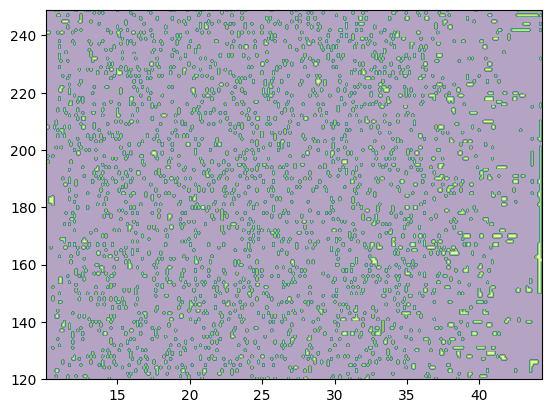

In [60]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Fit model
rf = RandomForestClassifier(n_estimators=200)
rf.fit(xAxis[['BMI','Cholesterol']], yAxis)

# Create grid
x_min, x_max = xAxis['BMI'].min(), xAxis['BMI'].max()
y_min, y_max = xAxis['Cholesterol'].min(), xAxis['Cholesterol'].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X['BMI'], X['Cholesterol'], c=yAxis, s=10, edgecolor='k')
